<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Global_Population_Pressure_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d sarcasmos/global-population-pressure-index

# Unziping the downloaded file
!unzip global-population-pressure-index.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sarcasmos/global-population-pressure-index
License(s): ODC Public Domain Dedication and Licence (PDDL)
  0% 0.00/811k [00:00<?, ?B/s]
100% 811k/811k [00:00<00:00, 710MB/s]
Archive:  global-population-pressure-index.zip
  inflating: README.md               
  inflating: global_population_risk.csv  
  inflating: population_goods_resources.csv  
  inflating: population_growth.csv   
  inflating: population_ozone_environment.csv  


In [3]:
df = pd.read_csv('population_ozone_environment.csv')
df.head(11)

,country,year,population,co2_emissions,cfc_consumption,ozone_thickness,uv_radiation_index,industrialization_index,energy_consumption_per_capita,policy_score
0,Afghanistan,1970,37485284,3.39,23.61,376.4,2.16,17.2,1.46,20.3
1,Albania,1970,95073894,1.66,26.97,364.6,3.15,17.8,0.86,38.5
2,Algeria,1970,73212794,1.82,52.69,356.7,2.61,17.6,2.01,32.7
3,Argentina,1970,59885915,12.64,95.88,399.9,2.14,55.8,4.21,32.1
4,Australia,1970,15644063,9.54,60.20,318.0,3.83,61.5,4.33,24.7
5,Austria,1970,15641652,17.26,93.97,368.5,2.22,58.7,4.07,39.5
6,Bangladesh,1970,134221237,4.65,51.79,353.3,2.93,18.2,1.50,20.5
7,Belgium,1970,86624305,11.01,98.16,386.3,1.79,64.3,5.61,39.3
8,Brazil,1970,921616767,11.30,94.05,318.5,3.69,64.4,6.55,21.9
9,Bulgaria,1970,70821854,4.60,40.73,397.4,2.25,21.2,0.96,36.2


In [4]:
df.tail(11)

,country,year,population,co2_emissions,cfc_consumption,ozone_thickness,uv_radiation_index,industrialization_index,energy_consumption_per_capita,policy_score
9005,Suriname,2025,5135371911427621981782016,4.10,8.89,327.9,3.11,39.8,1.94,89.9
9006,Syria,2025,1387195864454720603029504,5.86,9.94,317.2,3.57,39.8,2.59,88.3
9007,Tajikistan,2025,696523873020269071171584,3.30,7.58,330.7,3.81,39.1,2.73,85.9
9008,Togo,2025,2412235067487241956753408,7.02,8.39,287.8,4.67,37.5,2.81,86.2
9009,Trinidad and Tobago,2025,5024434054439552096927744,3.45,7.87,288.3,3.99,41.7,2.95,85.7
9010,Tunisia,2025,1053298964928954080690176,6.25,4.49,293.4,4.56,39.4,2.99,90.1
9011,Turkmenistan,2025,3543514898310297169166336,6.94,0.89,284.0,3.87,37.6,2.11,94.0
9012,Uganda,2025,3598250310423094866477056,5.36,5.13,345.8,3.26,38.2,2.01,88.4
9013,United Arab Emirates,2025,1234255700191616834732032,17.60,2.04,309.3,4.29,82.1,8.94,86.3
9014,Uruguay,2025,4133600190530964076625920,4.24,2.41,316.3,3.81,41.4,2.62,89.8


In [5]:
df.shape

(9016, 10)

In [6]:
df.columns

Index(['country', 'year', 'population', 'co2_emissions', 'cfc_consumption',
       'ozone_thickness', 'uv_radiation_index', 'industrialization_index',
       'energy_consumption_per_capita', 'policy_score'],
      dtype='object')

In [7]:
df.dtypes

,0
country,object
year,int64
population,object
co2_emissions,float64
cfc_consumption,float64
ozone_thickness,float64
uv_radiation_index,float64
industrialization_index,float64
energy_consumption_per_capita,float64
policy_score,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9016 entries, 0 to 9015
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        9016 non-null   object 
 1   year                           9016 non-null   int64  
 2   population                     9016 non-null   object 
 3   co2_emissions                  9016 non-null   float64
 4   cfc_consumption                9016 non-null   float64
 5   ozone_thickness                9016 non-null   float64
 6   uv_radiation_index             9016 non-null   float64
 7   industrialization_index        9016 non-null   float64
 8   energy_consumption_per_capita  9016 non-null   float64
 9   policy_score                   9016 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 704.5+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,9016,161,Afghanistan,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,9016.0,NaN,NaN,NaN,1997.5,16.164126,1970.0,1983.75,1997.5,2011.25,2025.0
population,9016,9016,2266741133549561939230720,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
co2_emissions,9016.0,NaN,NaN,NaN,8.086928,6.452634,0.26,3.51,5.14,13.2825,24.98
cfc_consumption,9016.0,NaN,NaN,NaN,27.720414,26.568467,0.0,5.35,19.585,46.1725,100.0
ozone_thickness,9016.0,NaN,NaN,NaN,321.684039,34.796547,243.3,295.8,317.9,345.0,419.1
uv_radiation_index,9016.0,NaN,NaN,NaN,3.566044,0.752874,1.23,3.06,3.64,4.11,5.86
industrialization_index,9016.0,NaN,NaN,NaN,44.132032,22.222716,17.1,25.8,36.9,64.7,90.0
energy_consumption_per_capita,9016.0,NaN,NaN,NaN,3.277685,2.466079,0.4,1.57,2.13,5.09,10.29
policy_score,9016.0,NaN,NaN,NaN,66.147527,26.7224,20.0,36.2,82.6,88.8,95.0


In [10]:
df.isnull().sum()

,0
country,0
year,0
population,0
co2_emissions,0
cfc_consumption,0
ozone_thickness,0
uv_radiation_index,0
industrialization_index,0
energy_consumption_per_capita,0
policy_score,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

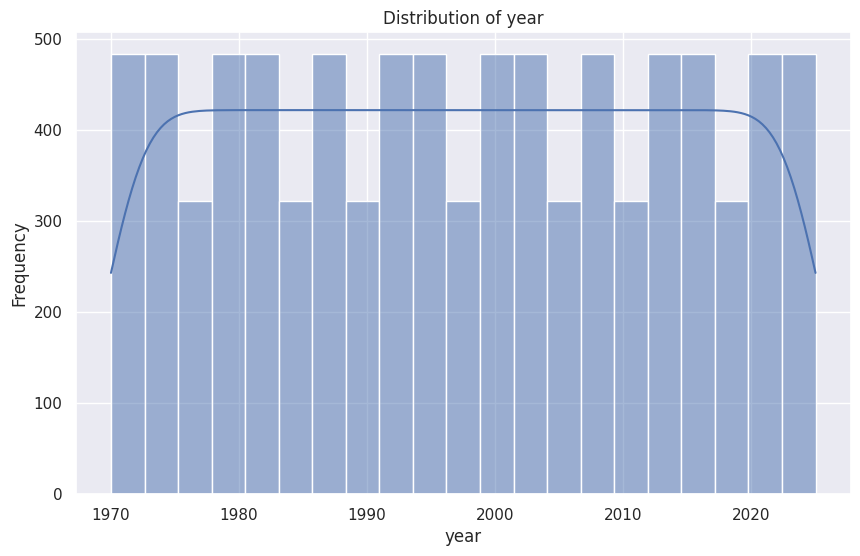

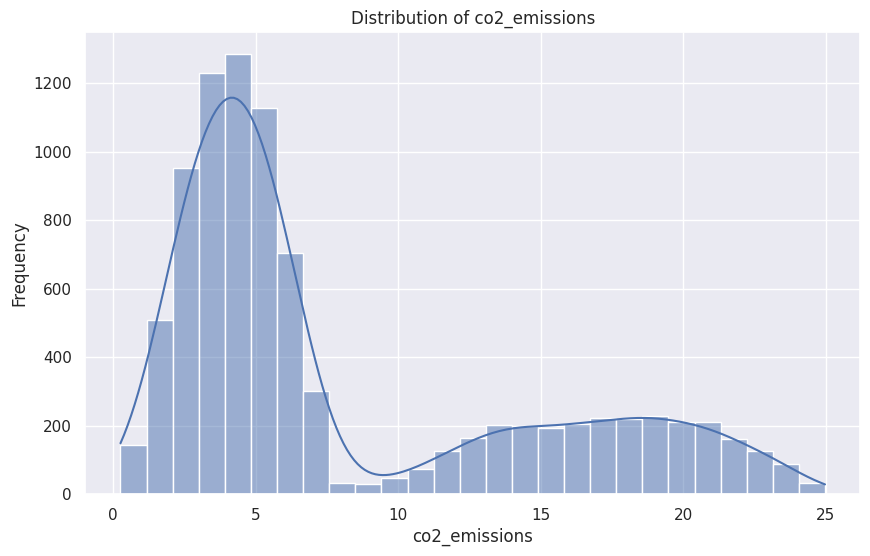

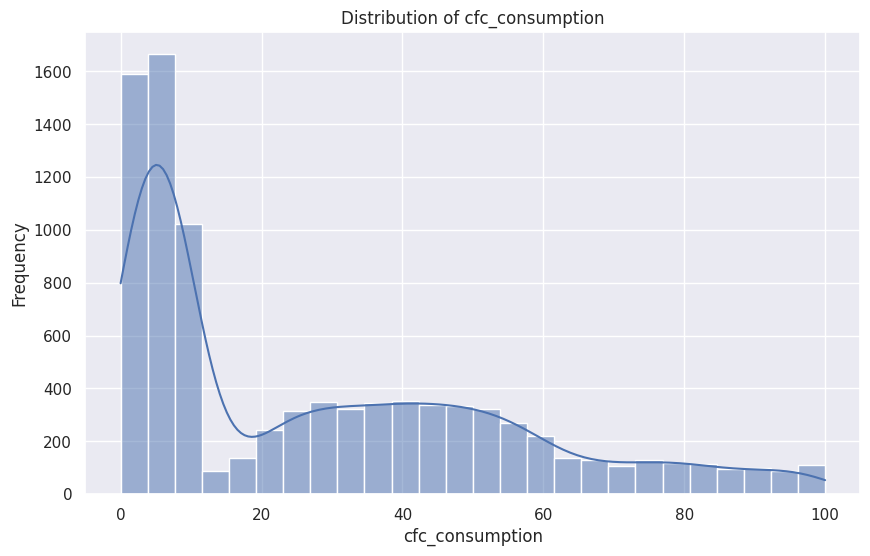

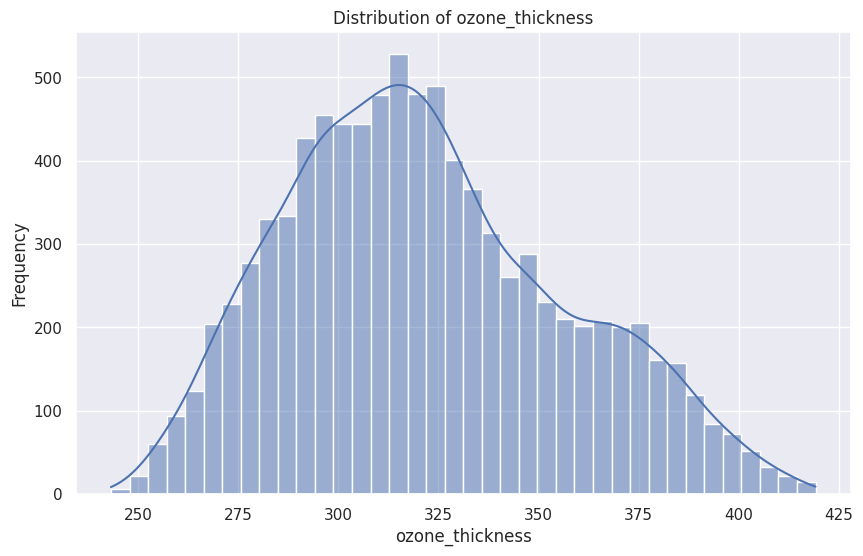

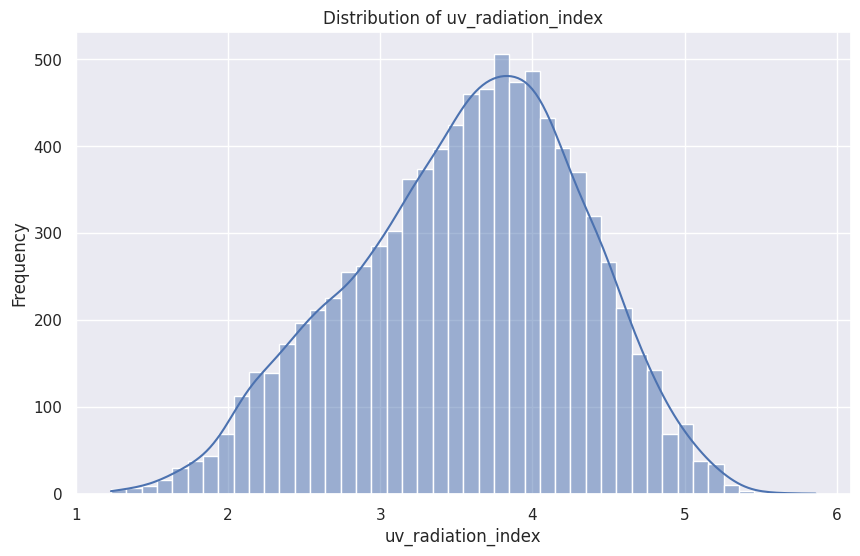

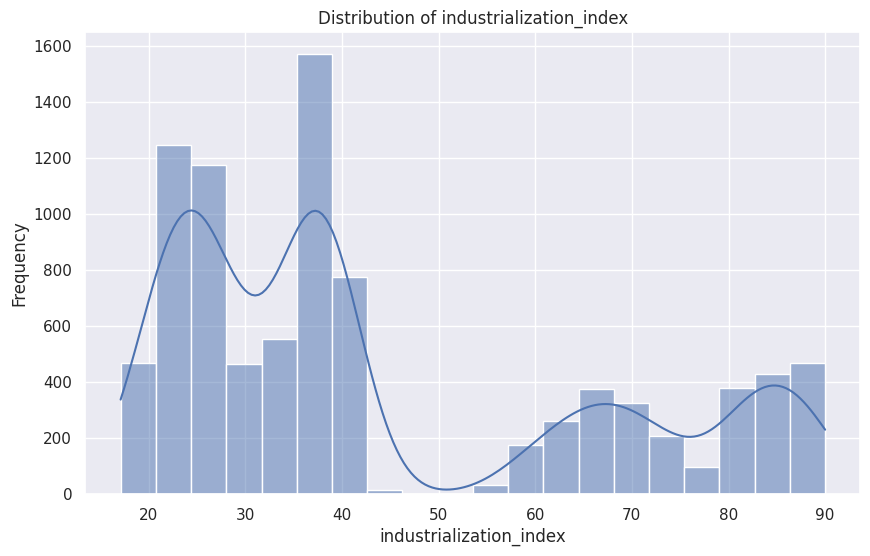

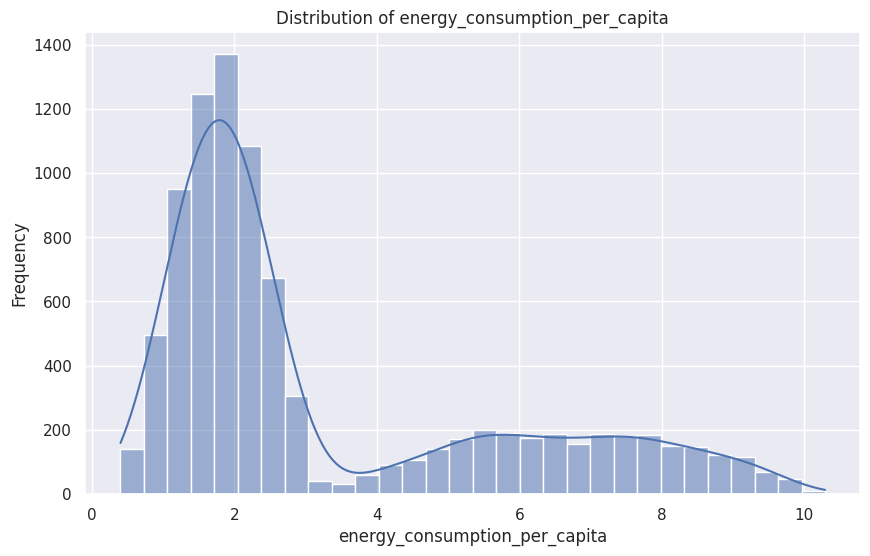

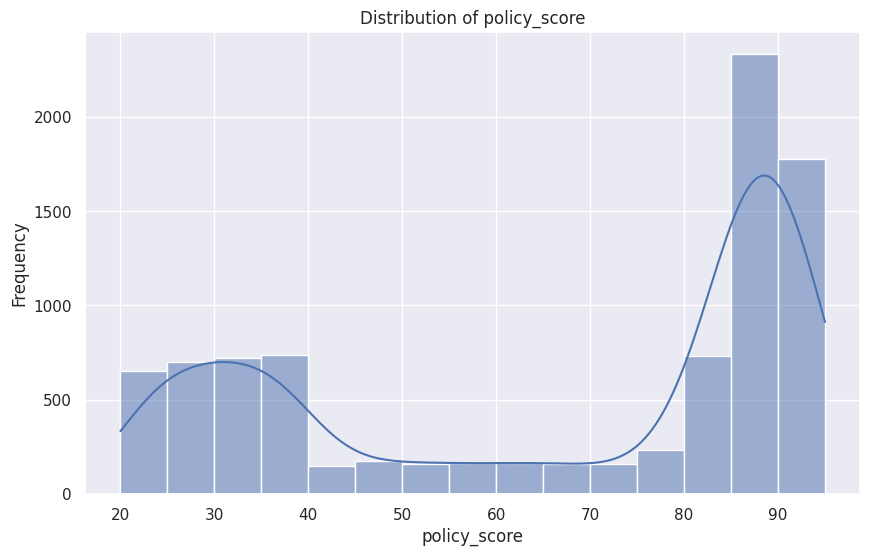

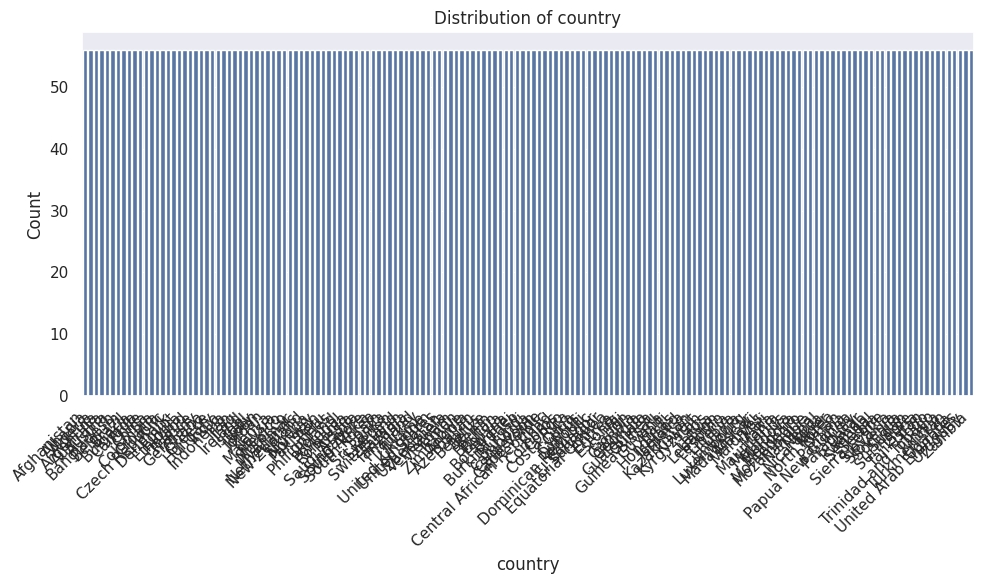

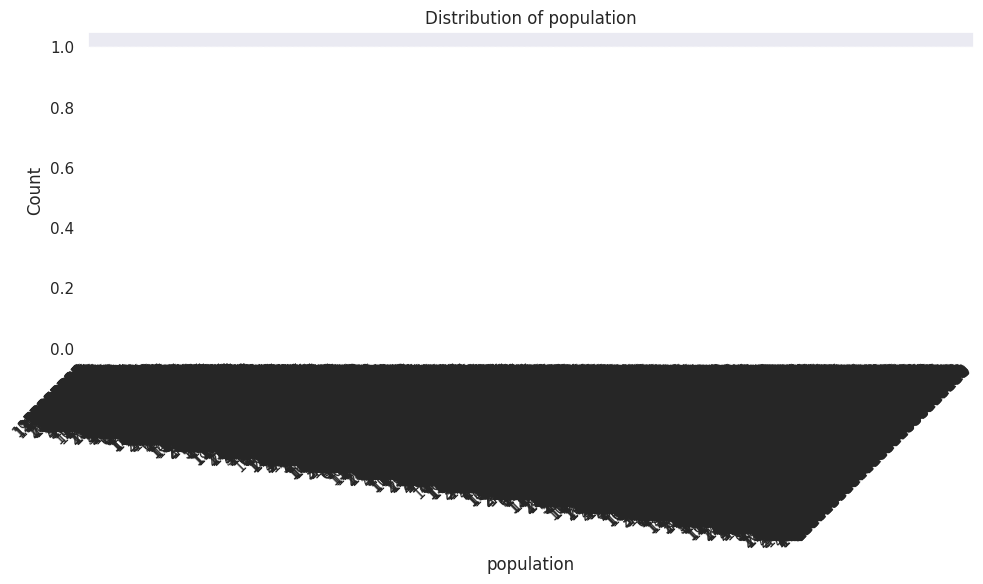

Value counts for country:
country
Afghanistan             56
Albania                 56
Algeria                 56
Argentina               56
Australia               56
                        ..
Turkmenistan            56
Uganda                  56
United Arab Emirates    56
Uruguay                 56
Zambia                  56
Name: count, Length: 161, dtype: int64

Value counts for population:
population
2266741133549561939230720    1
37485284                     1
95073894                     1
73212794                     1
59885915                     1
                            ..
1257041829                   1
96992489                     1
2107420                      1
70821854                     1
921616767                    1
Name: count, Length: 9016, dtype: int64



In [13]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

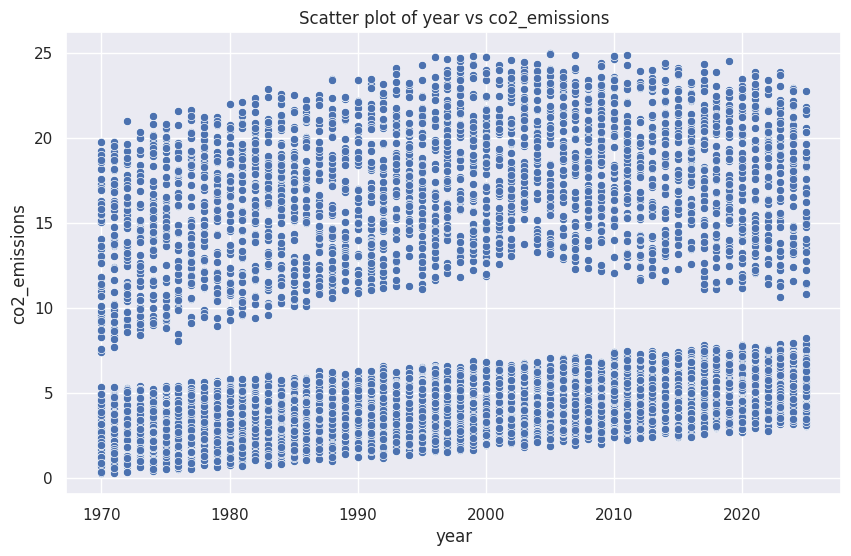

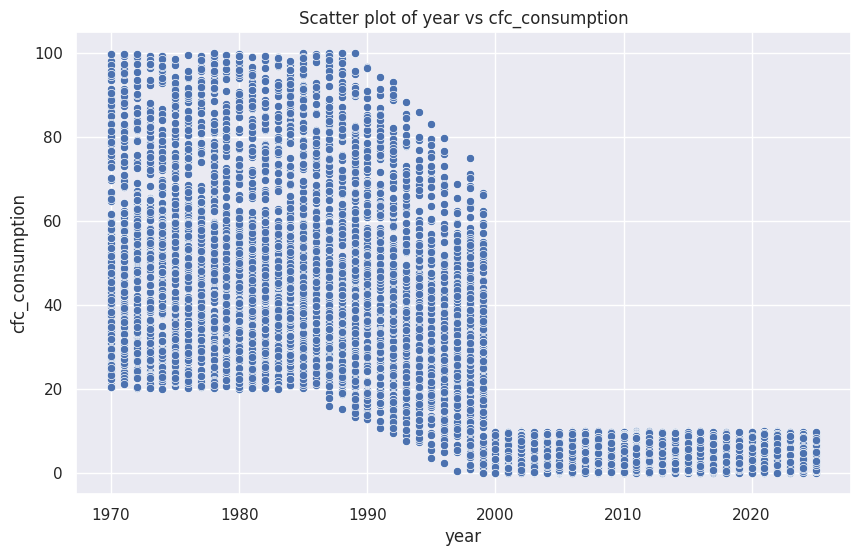

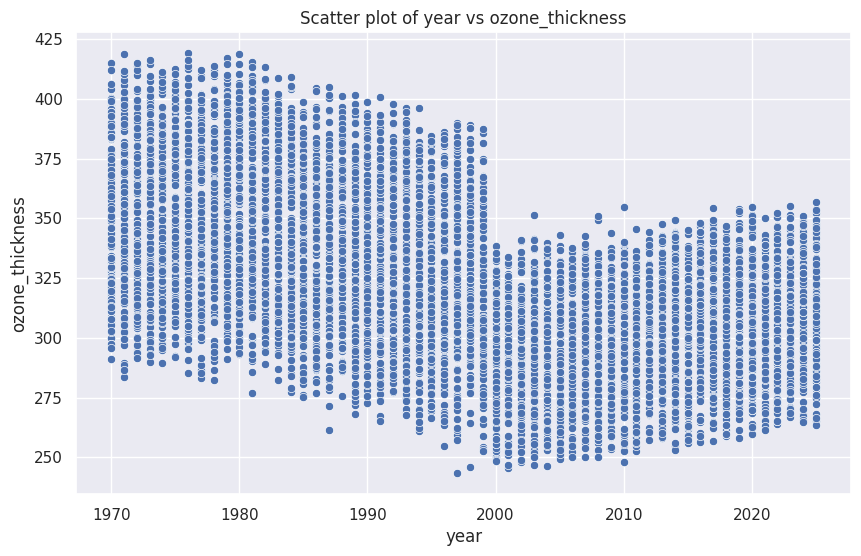

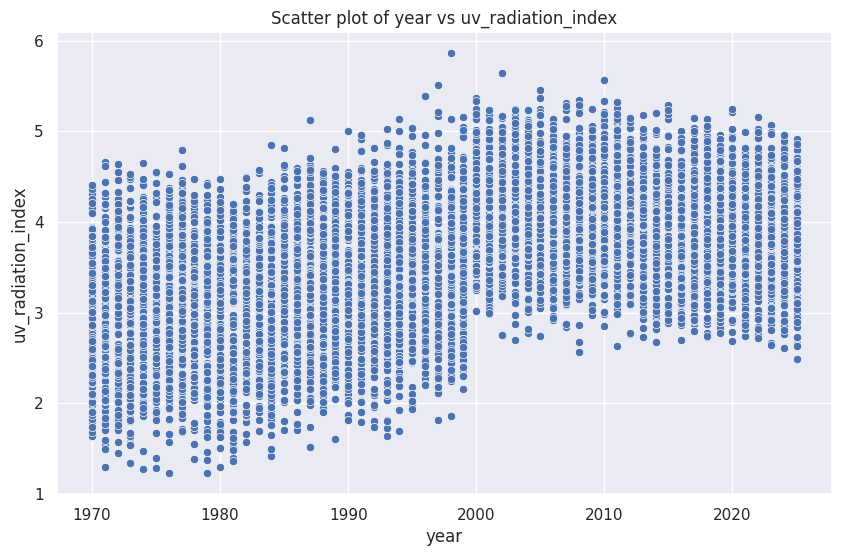

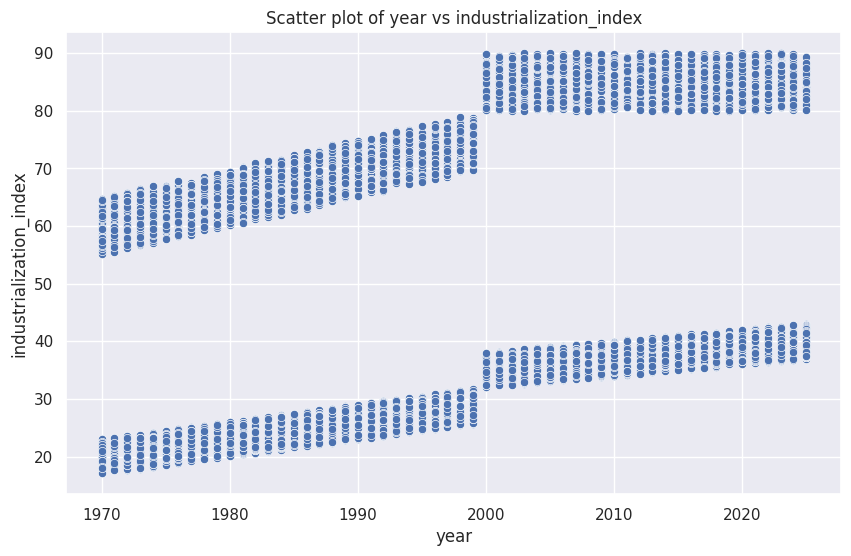

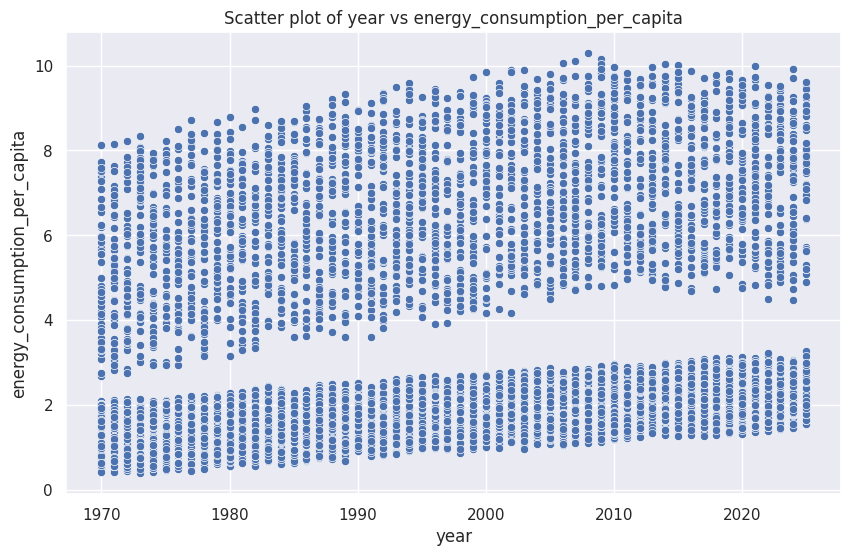

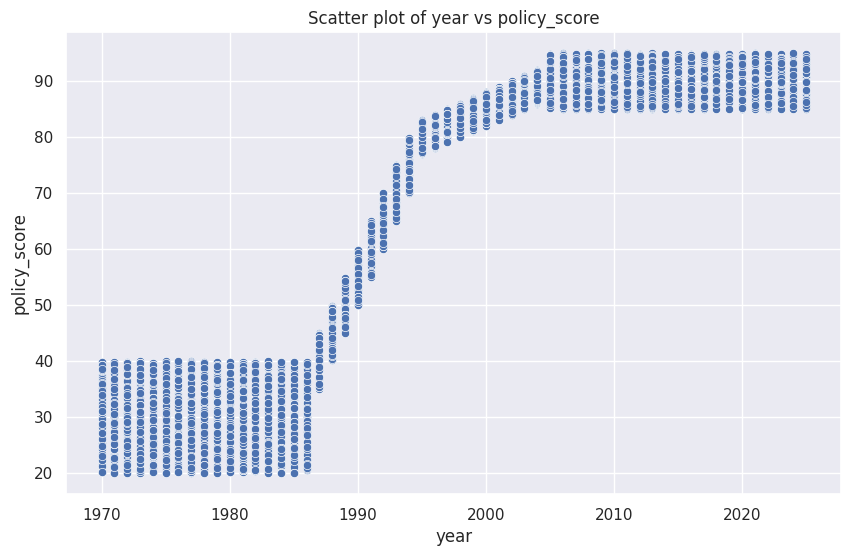

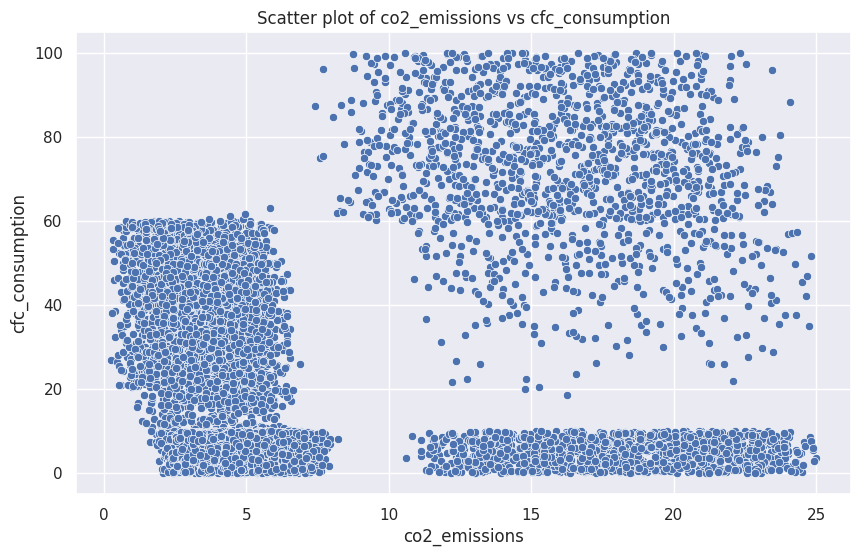

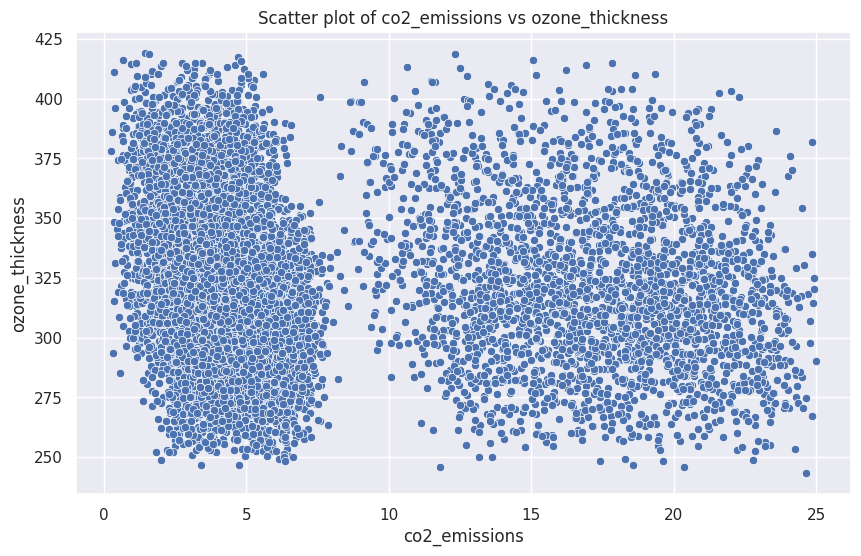

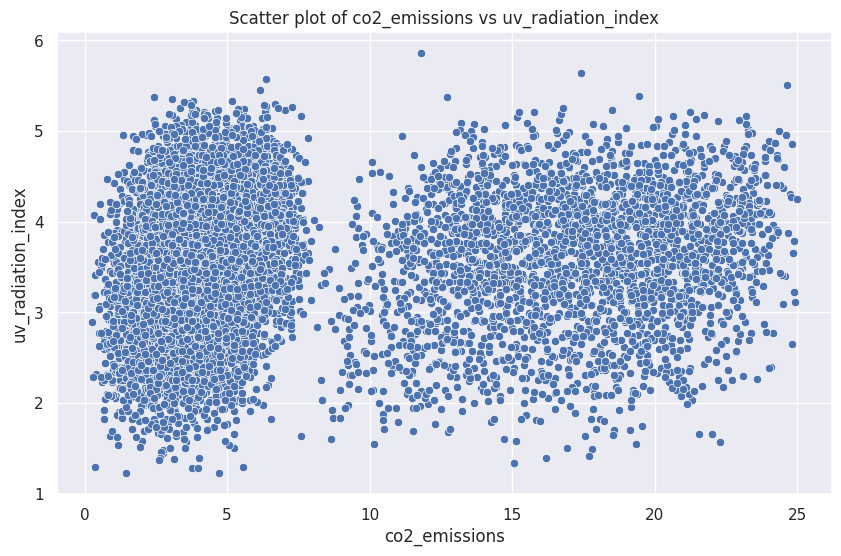

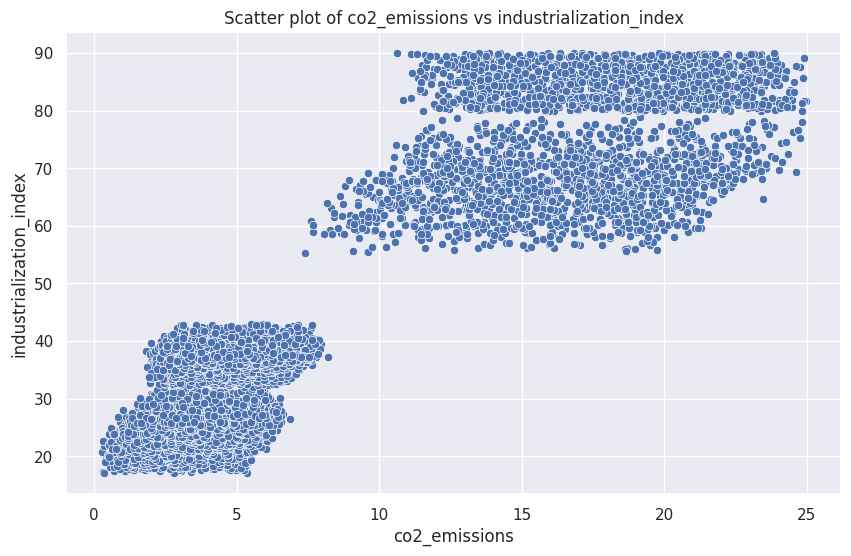

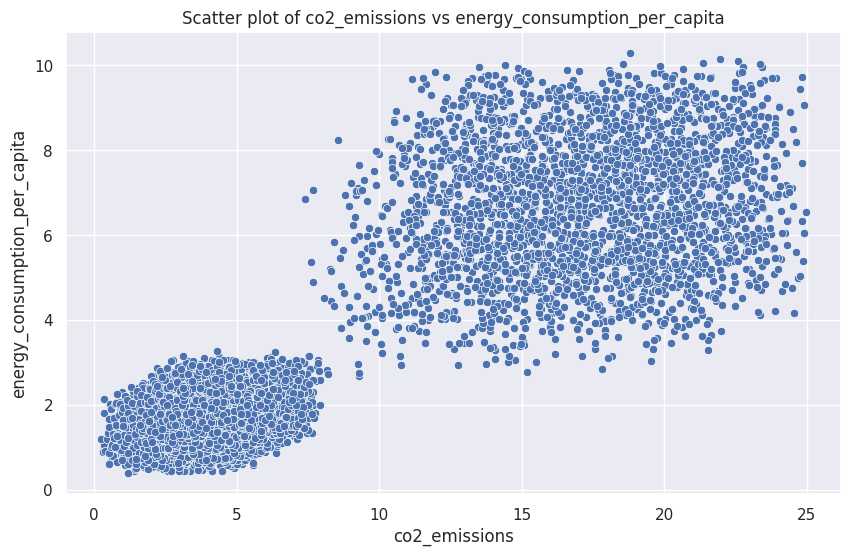

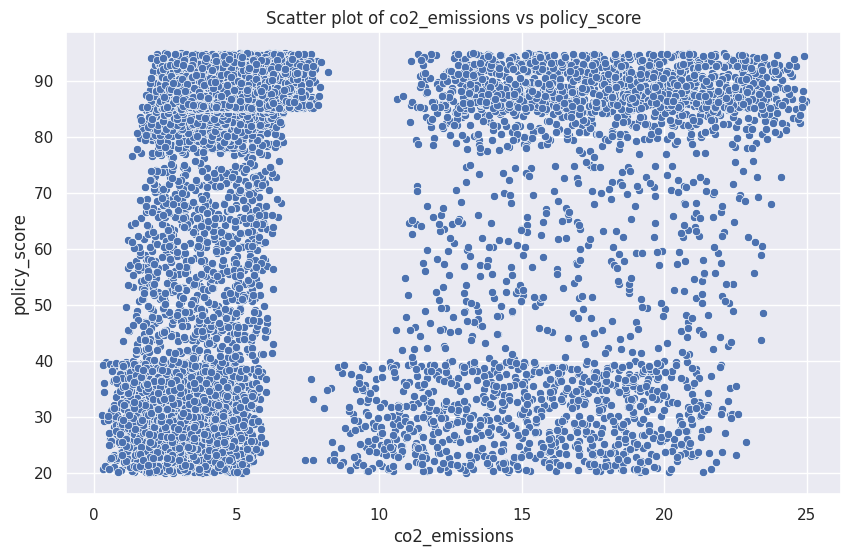

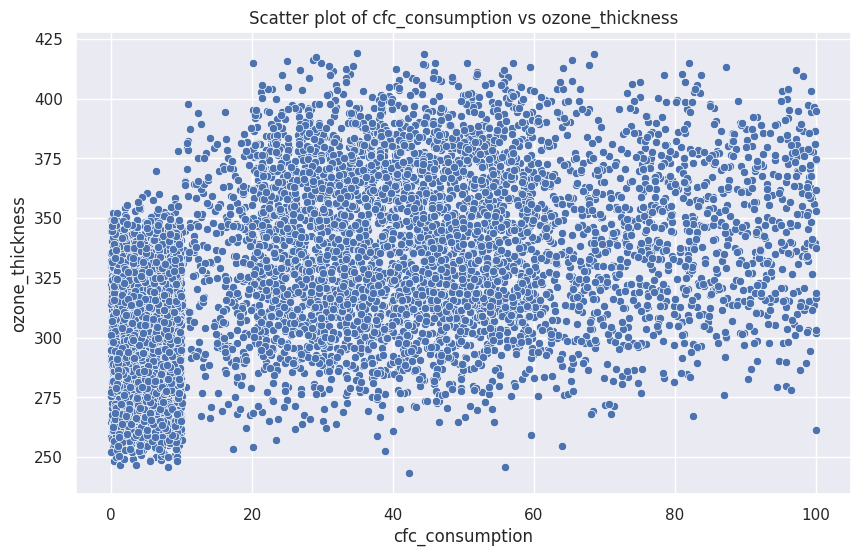

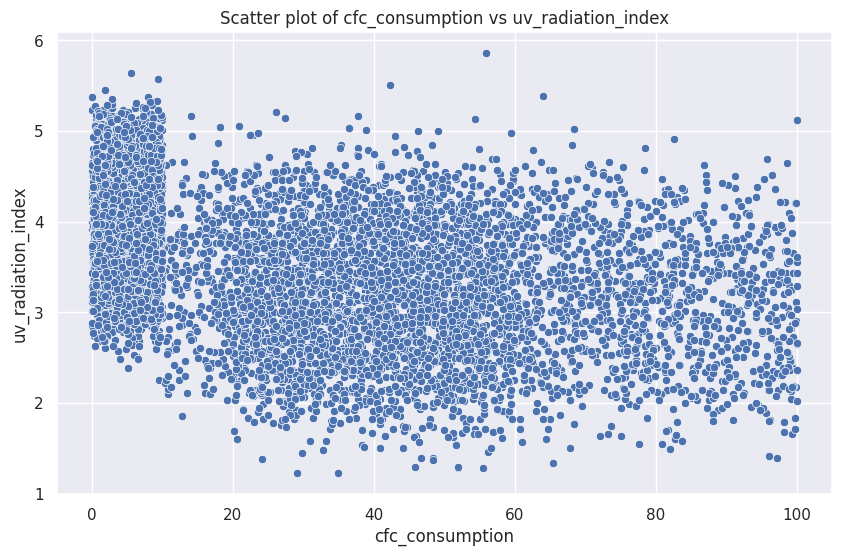

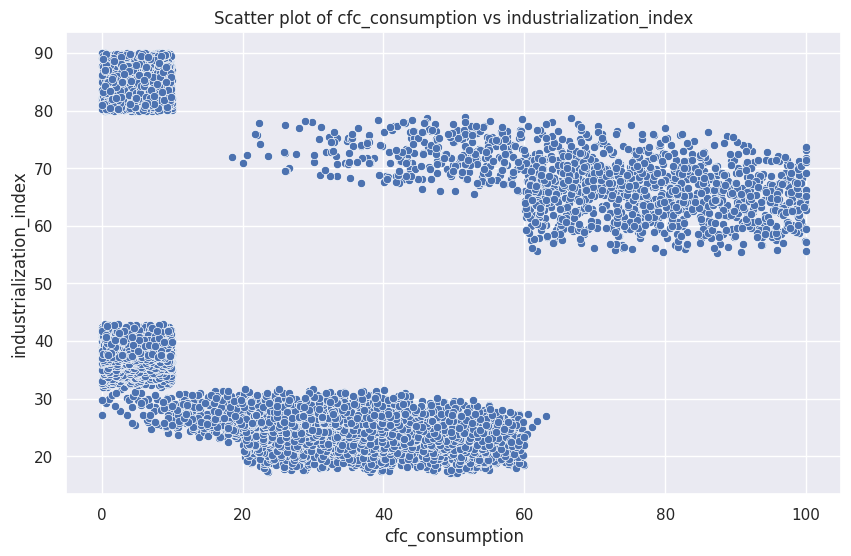

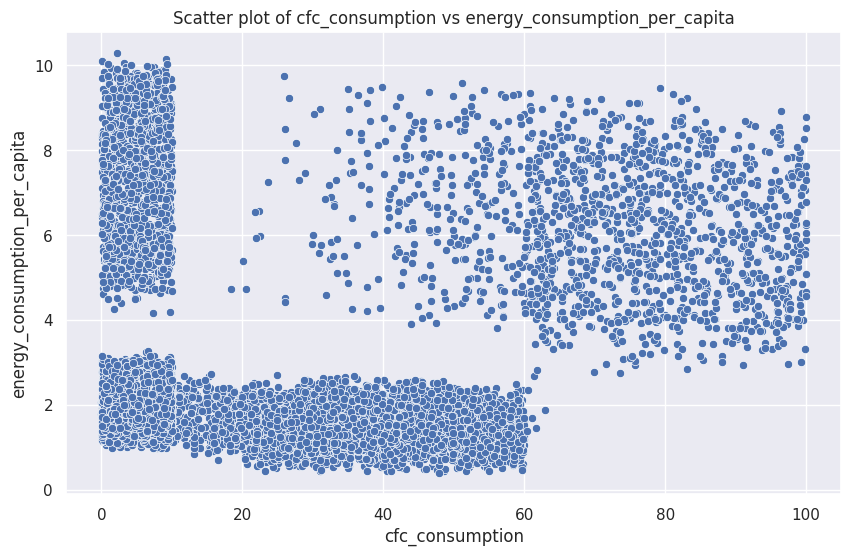

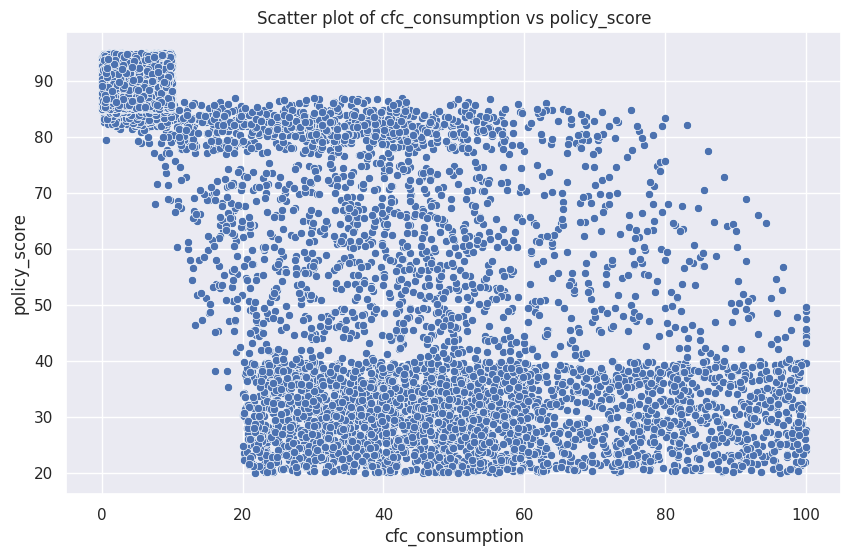

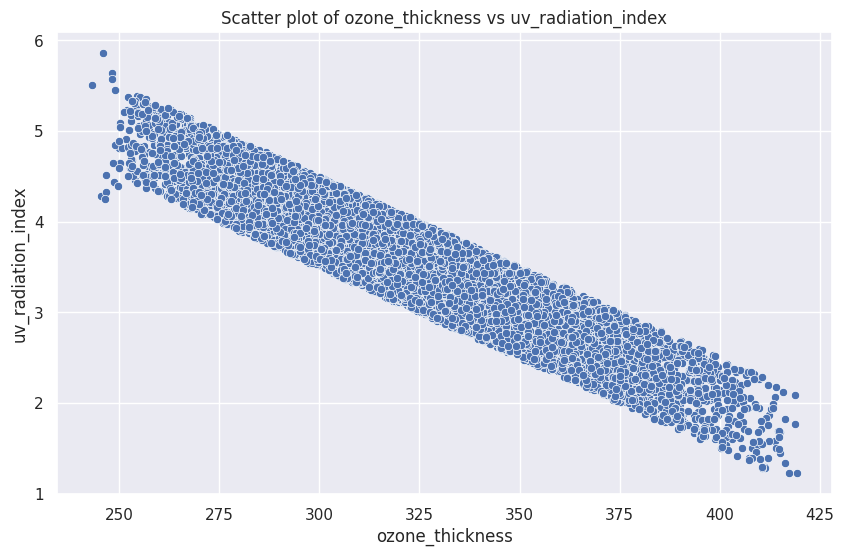

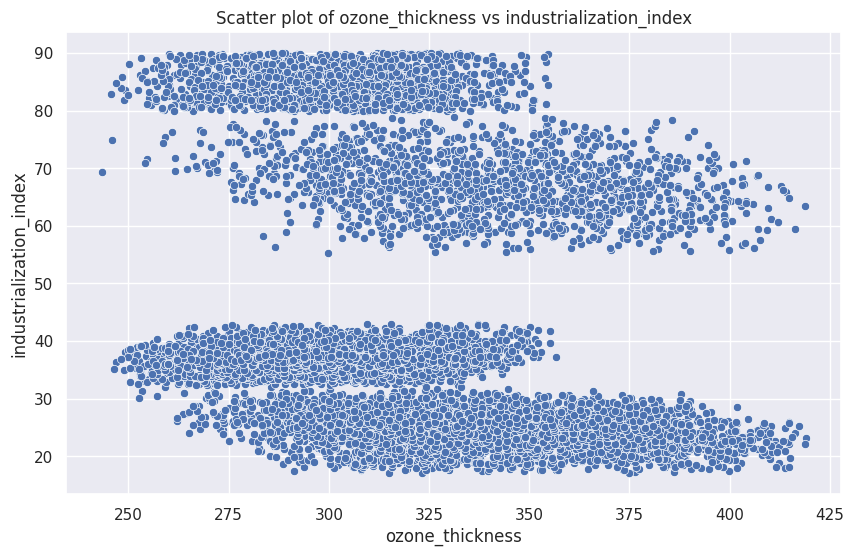

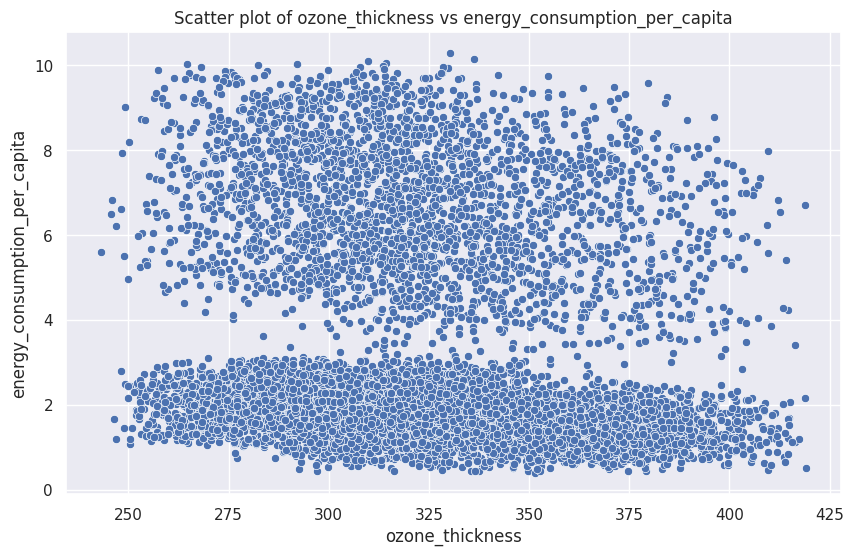

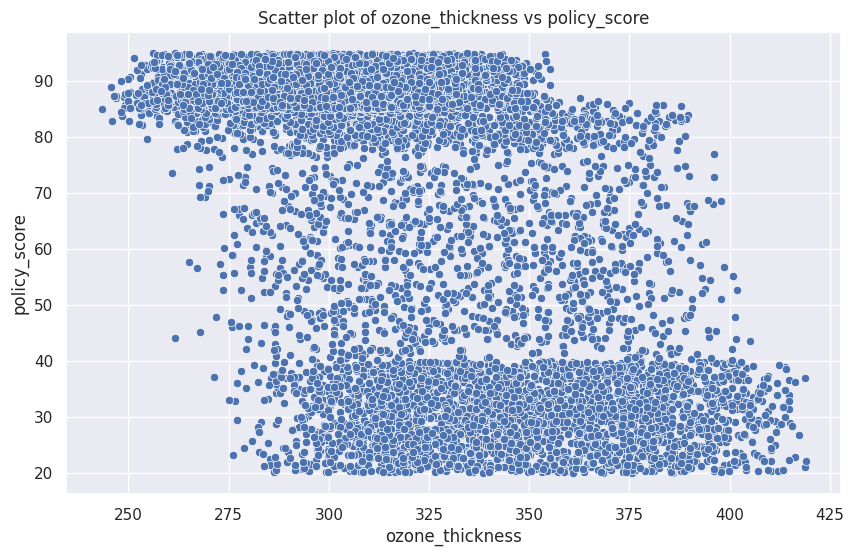

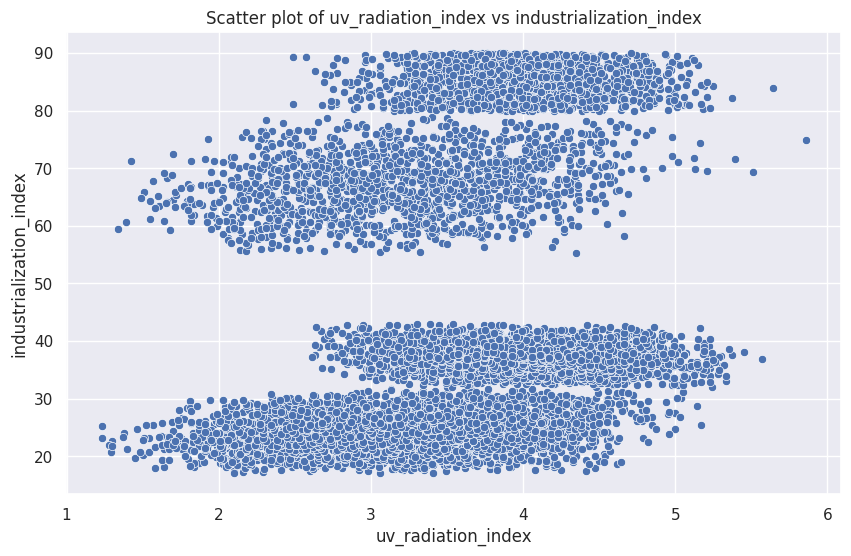

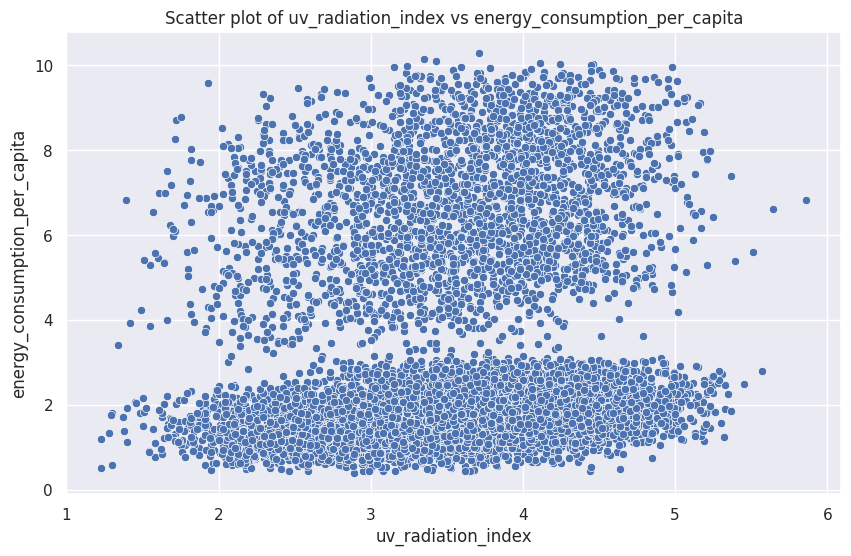

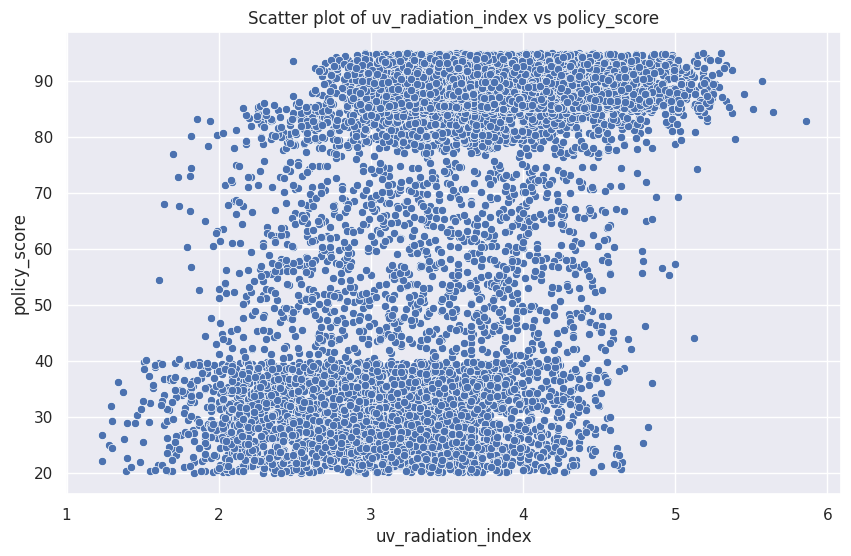

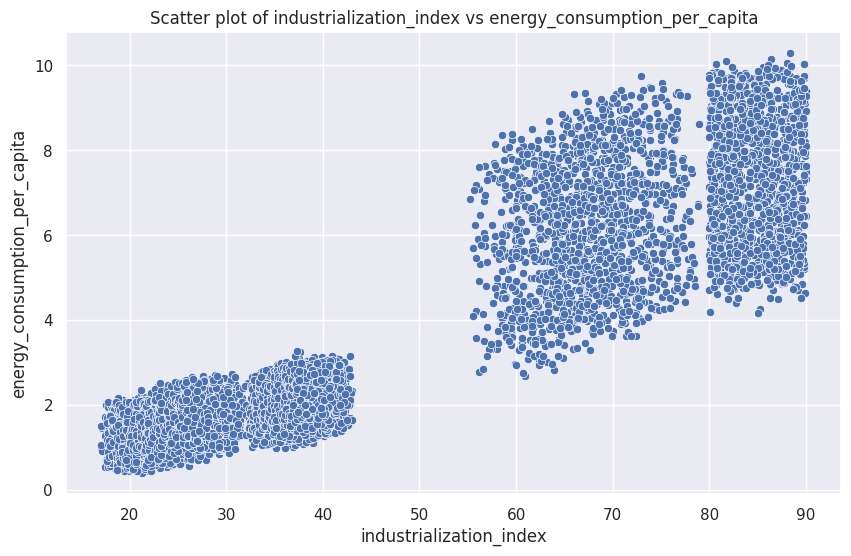

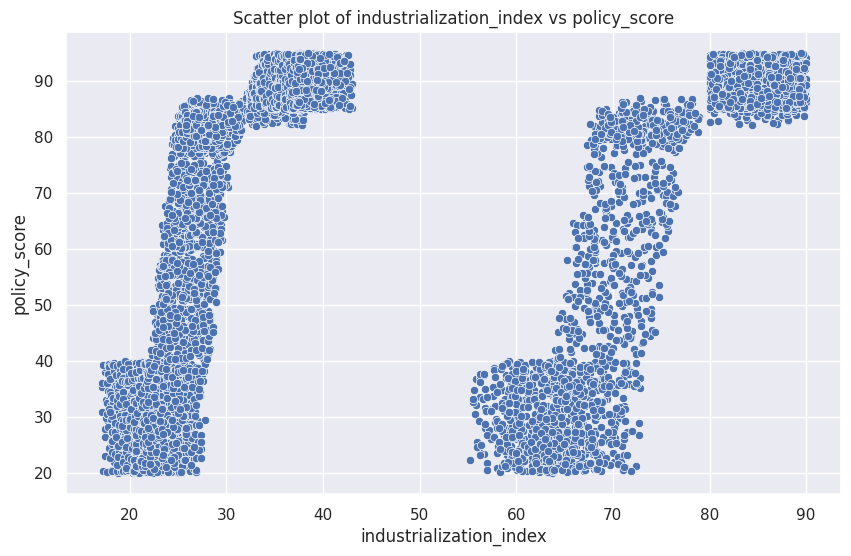

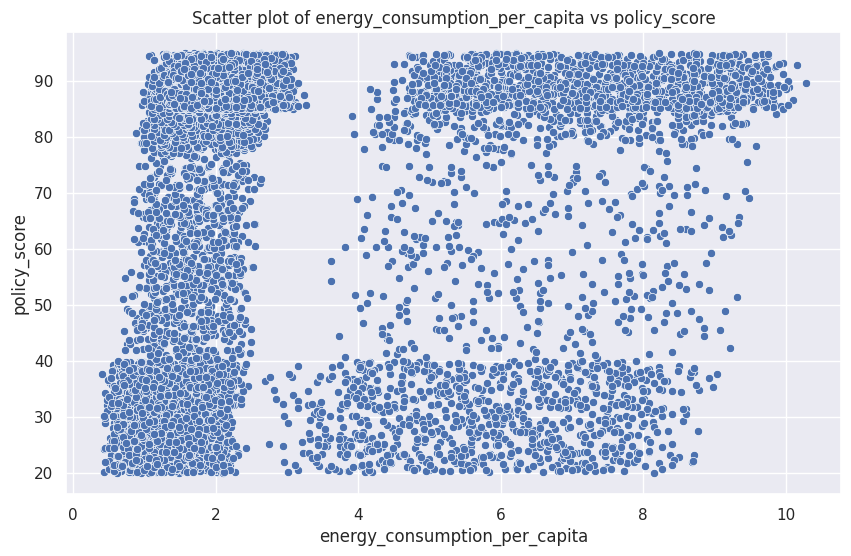

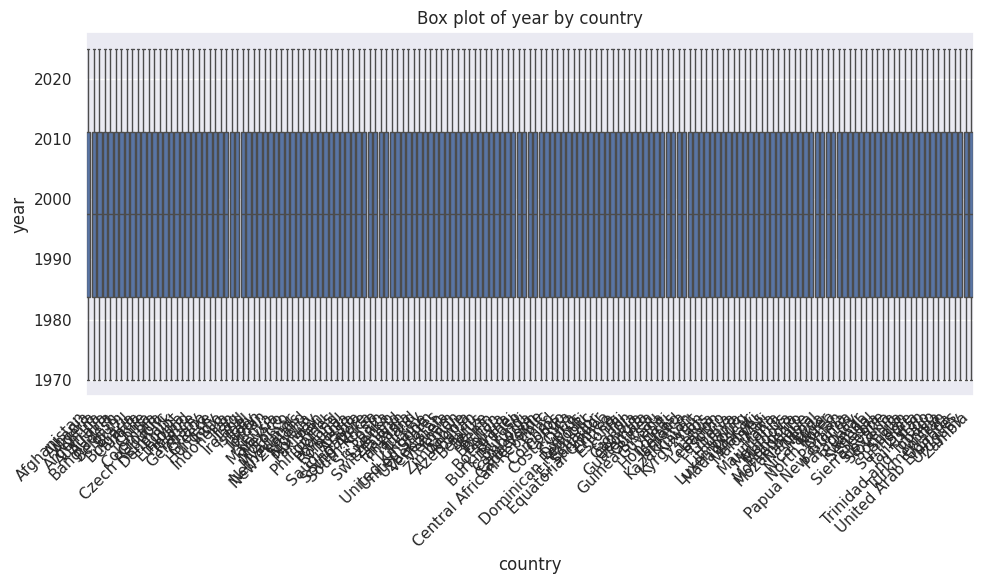

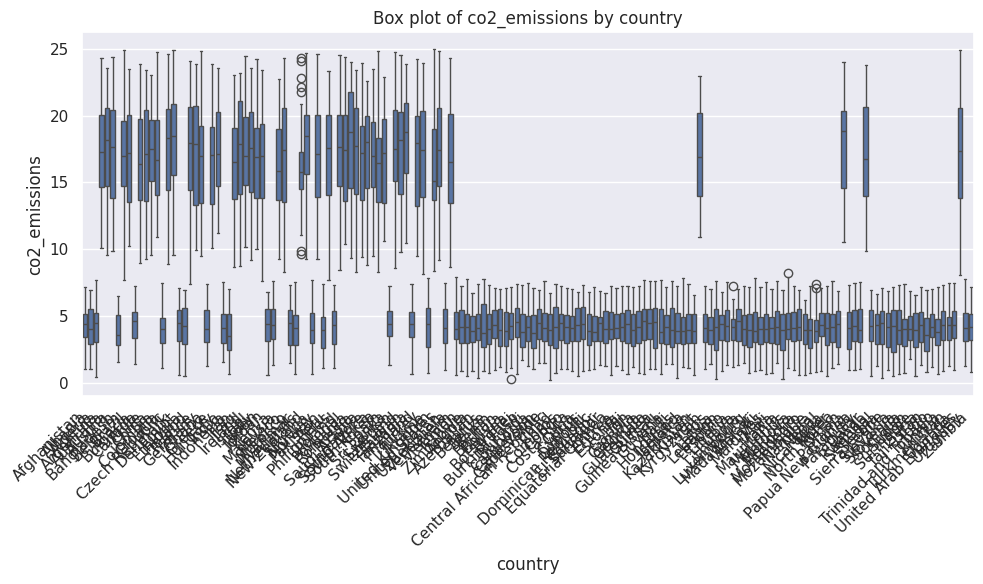

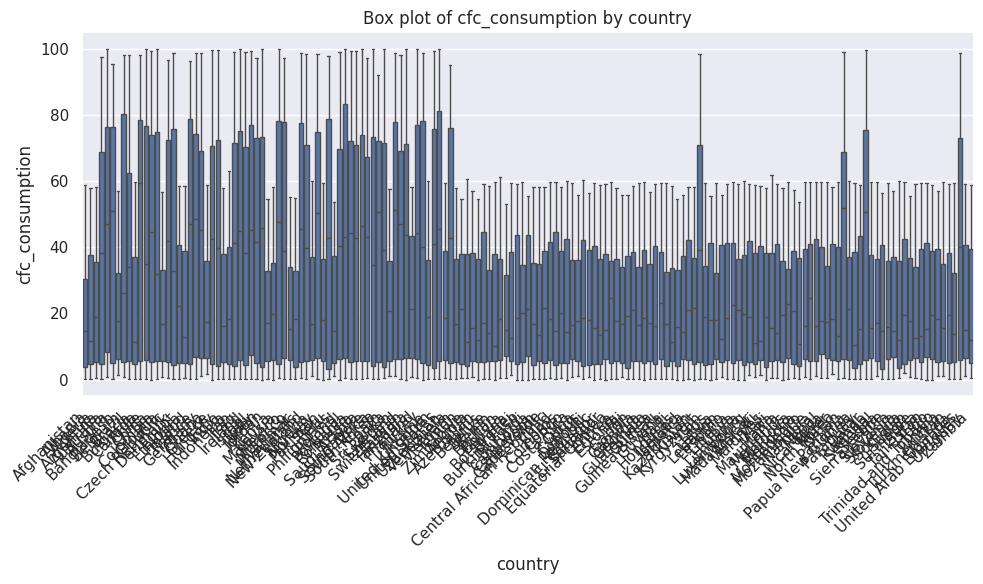

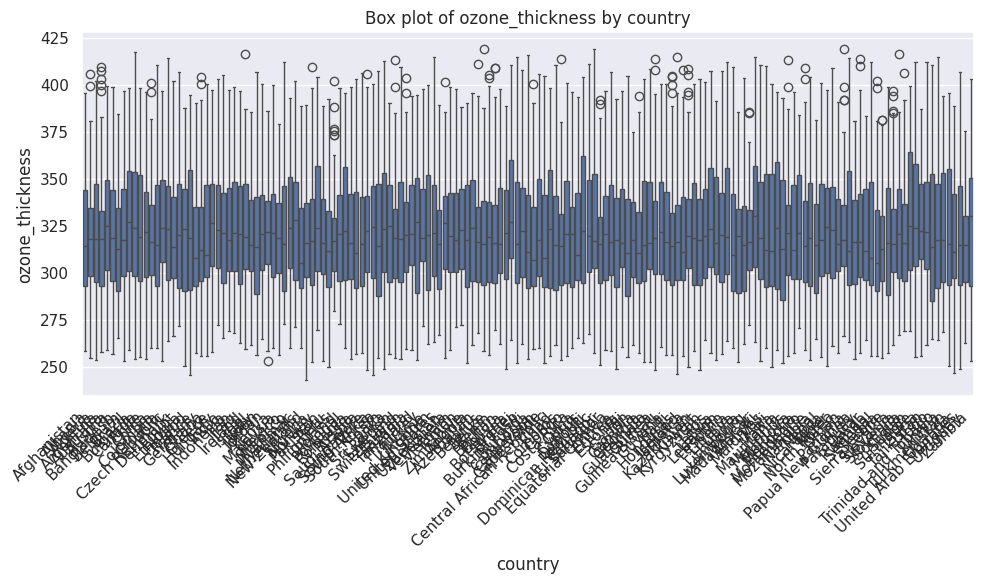

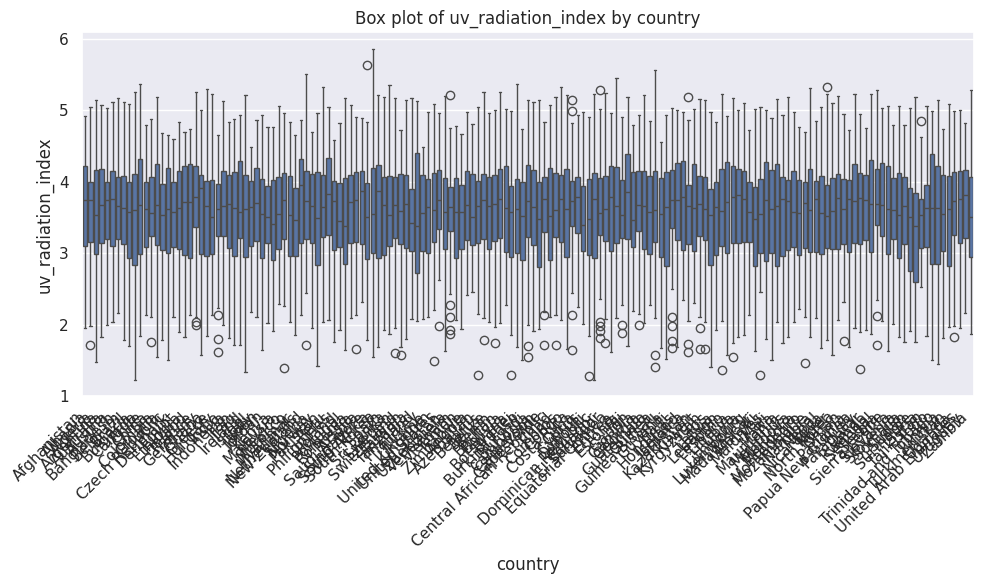

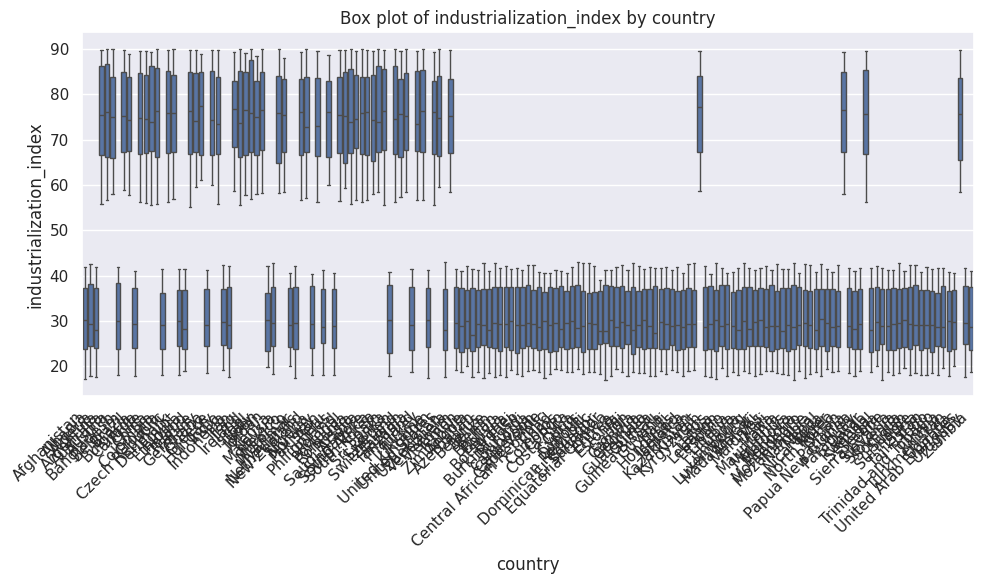

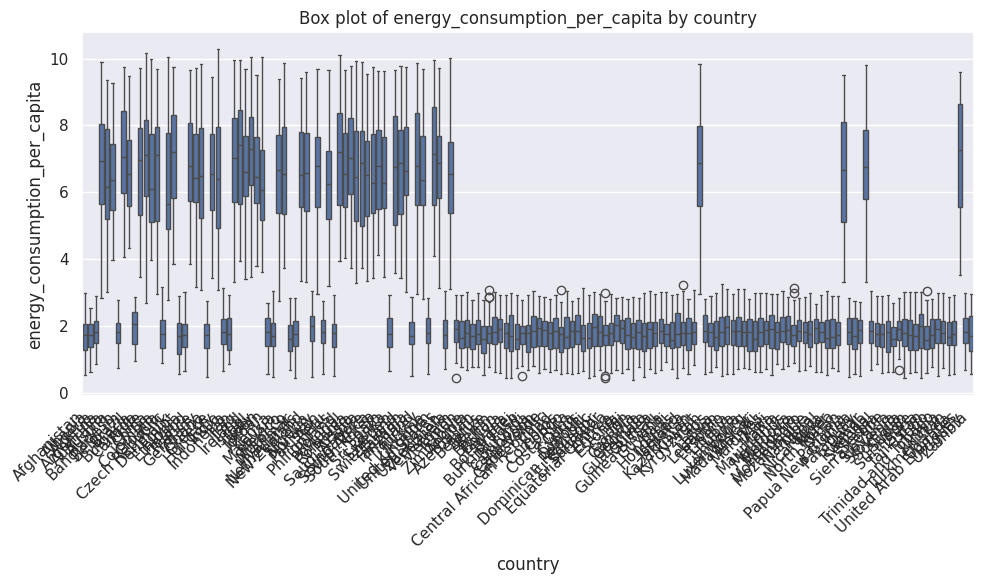

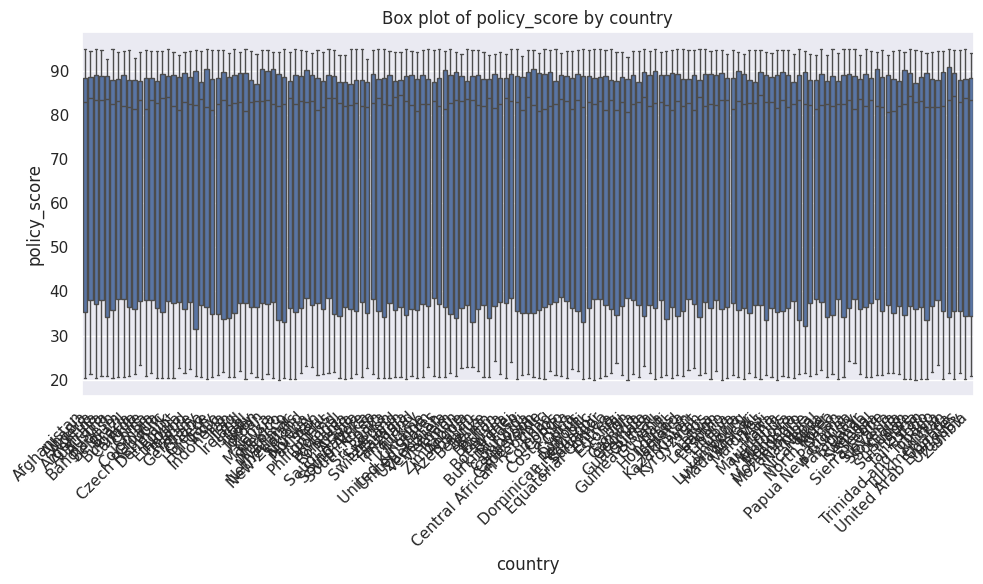

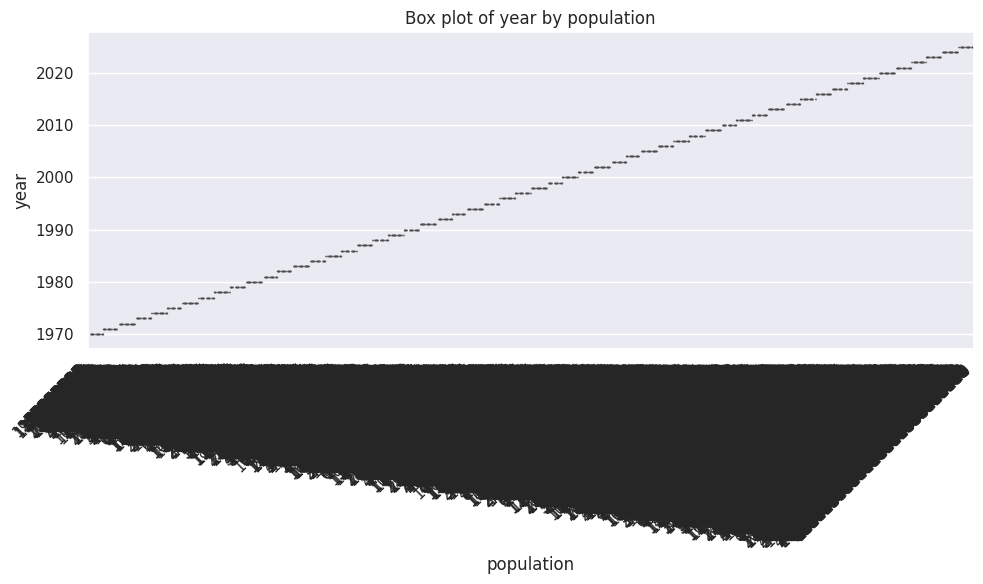

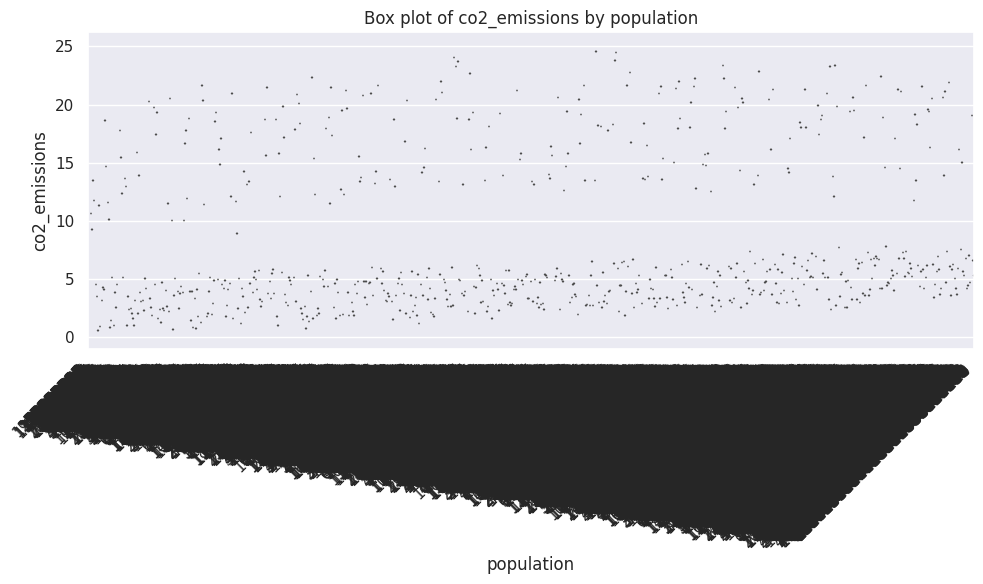

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [ ]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You